# Introducción

# Análisis Económico Regional de Chile (2013–2024)
**Fuente:** Banco Central de Chile — API `bcchapi`

## Contexto y Motivación

Chile es un país geográficamente diverso, con regiones cuya base
económica se ha entrado en discucion en los ultimos años: desde la minería del cobre en el norte
hasta la pesca y el turismo en el sur. Sin embargo, gran parte del
debate económico nacional se concentra en cifras agregadas que ocultan
las diferencias regionales.

Este proyecto nace de la siguiente pregunta:

> **¿Que regiones de Chile están creciendo más y qué factores
> explican ese crecimiento? y ¿Que sectores son los principales contribuyentes al PIB del pais?**

Para responderla, se utilizaron datos oficiales del Banco Central de
Chile, analizando el PIB anual de las 16 regiones y sus sectores
productivos entre 2013 y 2024. El análisis busca identificar patrones
de crecimiento, anticipar cambios estructurales en la economía regional
y entender cómo eventos como la pandemia COVID-19 afectaron de forma
diferenciada a cada territorio.

Como variable complementaria, se incorporaron datos de generación
eléctrica regional para explorar si la actividad energética anticipa
o sigue al crecimiento económico.

# Lectura de datos

##Librerias python y banco central

In [ ]:
pip install bcchapi

In [ ]:
import bcchapi
import requests
import numpy as np
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

### Prueba rapida de datasets

In [ ]:
siete = bcchapi.Siete(file="user.txt")

In [ ]:
df_arica=siete.buscar("Región de Arica")

In [ ]:
df_arica.frequencyCode.unique()

array(['QUARTERLY', 'MONTHLY', 'DAILY', 'ANNUAL'], dtype=object)

In [ ]:
lista_dataset= ["Tasa de desocupación, ", 'Empleo: ', ]
lista_electrcidad = ['Generación eléctrica, MWh; ','Distribución eléctrica, MWh;']
lista_turismo = ["Encuesta mensual de alojamiento turístico (EMAT)"]
lista_servicios_quar = [", volumen a precios del año anterior encadenado, referencia 2018 (miles de millones de pesos encadenados)"]
lista_servicios_anuales = [' precios corrientes, base 2018']

lista_empresa = [ 'Región de Arica y Parinacota, Número de constituciones en registro de empresas y sociedades a nivel regional; mensual;  cantidad; MINECON']
lista_cc ={'Saldo promedio de cuentas corrientes de personas naturales en moneda extranjera;',
       'Saldo promedio de cuentas corrientes de personas naturales en moneda nacional;','Número de cuentas corrientes de personas naturales en moneda extranjera; ', 'Número de cuentas corrientes de personas naturales en moneda nacional;'}

In [ ]:
df_arica[df_arica.frequencyCode == "ANNUAL"].spanishTitle.unique();

##Nota


Los años indican los acumulado entre el 1 de enero al 31 de diciembre

## Regiones y servicios

### Carga de datos

In [ ]:
lista_servicios_anuales[0]

' precios corrientes, base 2018'

In [ ]:
df_servicios_per_region = siete.buscar(lista_servicios_anuales[0])

In [ ]:
def ajuste_df_serie(df_per_region):
  df_temp = df_per_region.copy()
  df_temp [["Titulo","Región"]]=df_temp.spanishTitle.str.split(" Región ",expand=True)
  df_temp['Región'] = df_temp['Región'].str.split(",",n=1,expand=True)[0]
  df_temp['Región'] = df_temp['Región'].str.replace("de ","")
  df_temp['Región'] = df_temp['Región'].str.strip()

  df_temp['Titulo'] = df_temp['Titulo'].str.replace(",","")
  df_temp['Titulo'] = df_temp['Titulo'].str.strip()
  return df_temp

In [ ]:
df_servicios_per_region = ajuste_df_serie(df_servicios_per_region)
df_servicios_per_region.Titulo.unique()

array(['PIB subtotal regionalizado precios corrientes base 2018 (miles de millones de pesos)',
       'PIB Agropecuario-silvícola', 'PIB Pesca', 'PIB Minería',
       'PIB Industria manufacturera', 'PIB Electricidad gas y agua',
       'PIB Construcción', 'PIB Transportes y comunicaciones',
       'PIB Servicios financieros y empresariales',
       'PIB Propiedad de vivienda', 'PIB Servicios de vivienda',
       'PIB Servicios personales', 'PIB Administración pública',
       'PIB Comercio', 'PIB Comercio restaurantes y hotele',
       'PIB Restaurantes y hoteles', 'PIB',
       'Extrarregional precios corrientes base 2018 (miles de millones de pesos)'],
      dtype=object)

In [ ]:
def datos_regionales(df_servicios_per_region):
  dfs_serv_reg=[]
  url = "https://si3.bcentral.cl/SieteRestWS/SieteRestWS.ashx"
  for idx, serie in enumerate(df_servicios_per_region.seriesId.values):

    params = {
        "user": "rodolfo.godoyarteaga@gmail.com",
        "pass": "Chihuahua12",
        "function": "GetSeries",
        "timeseries": serie,
        "firstdate": "2000-01-01",
        "lastdate": "2026-01-01"
    }
    response = requests.get(url, params=params).json()

    try:
        df = pd.DataFrame(response["Series"]["Obs"])
        df["Titulo"] = df_servicios_per_region["Titulo"][idx]

        df['Región'] = df_servicios_per_region["Región"][idx]

        #df_temp = pd.json_normalize(df["Obs"])
        #df = pd.concat([df, df_temp], axis=1)

        #df["value"] = df["Obs"].value.astype(float)

        dfs_serv_reg.append(df)
    except:
        print(f"Error en serie {serie}")

  df_final = pd.concat(dfs_serv_reg)

  df_final["Región"] = df_final['Región'].str.strip()
  df_final["Región"] = df_final['Región'].str.capitalize()
  df_final["value"]  = df_final["value"].astype(float)
  df_final['indexDateString'] = pd.to_datetime(df_final['indexDateString'])
  df_final.rename(columns = {'indexDateString':'Date'}, inplace= True)
  #df_final["Date"] = df_final["Date"].dt.strftime('%d-%m-%Y')
  return df_final

In [ ]:
df_final = datos_regionales(df_servicios_per_region)
df_final.Región.unique()

array([None, 'Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo',
       'Valparaíso', 'Del libertador general bernardo ohiggins',
       'Del maule', 'Del biobío', 'La araucanía', 'Los lagos',
       'Aysén del general carlos ibáñez del campo',
       'Magallanes y la antártica chilena', 'Metropolitana santiago',
       'Los ríos', 'Arica y parinacota', 'Del ñuble'], dtype=object)

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2712 entries, 0 to 11
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        2712 non-null   datetime64[ns]
 1   value       2712 non-null   float64       
 2   statusCode  2712 non-null   object        
 3   Titulo      2712 non-null   object        
 4   Región      2688 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 127.1+ KB


# Analisis Descriptivo

In [ ]:
[df_final[i].unique().shape[0] for i in df_final.columns]

[12, 2701, 1, 18, 17]

In [ ]:
df_final = df_final.drop(columns=["statusCode"])
df_final_servicios = df_final[df_final['Región'].isna()==False]
df_final_servicios = df_final_servicios[df_final_servicios['Titulo'] != "PIB"]
df_final_servicios = df_final_servicios.reset_index()

##Analisis Por Región

**¿Cuáles son los tres servicios que más aportan al PIB de cada región?**
**¿Qué sectores productivos dominan a nivel nacional en el período
2013–2024?**

##### Confeccion de funciones

In [ ]:
def tendencia(x):
    return linregress(range(len(x)), x).slope

In [ ]:
def Analisis_PIB(df, region, postpre = None, fecha = None):
  '''

  '''
  region = region.capitalize()
  region = region.strip()
  if region in df["Región"].unique():
    pass
  else:
    return print("Debes ingresar una region valida")
  df_descriptivo = df[df['Región'] == region]

  df_descriptivo = df_descriptivo.sort_values(['Titulo', 'Date'])
  df_descriptivo["variación interanual"] = (df_descriptivo.groupby("Titulo")["value"].pct_change()*100).round(2)

  if postpre == "post":
    df_descriptivo_pp = df_descriptivo[df_descriptivo['Date'] > fecha]
  elif postpre == "pre":
    df_descriptivo_pp = df_descriptivo[df_descriptivo['Date'] < fecha]
  elif postpre == None:
    df_descriptivo_pp = df_descriptivo.copy()
  else:
    return print("Se tiene que ingresar 'post' o 'pre'. ")

  n = df_descriptivo_pp["Date"].unique().shape[0]

  #Analisis
  df_descri = []

  df_descri.append(df_descriptivo_pp.groupby("Titulo")["value"].apply(lambda x: (x.iloc[-1] / (x.iloc[0] +1e-6) - 1) * 100).rename('Crecimiento acumulado'))
  df_descri.append(df_descriptivo_pp.groupby("Titulo")["value"].apply(tendencia).rename('Tendencia (Var)'))
  df_descri.append(df_descriptivo_pp.dropna().groupby("Titulo")["variación interanual"].mean().rename('Media'))
  df_descri.append(df_descriptivo_pp.dropna().groupby("Titulo")["variación interanual"].std().rename('Std'))
  df_descri = pd.concat(df_descri,axis=1)
  df_descri["Volatilidad"] = pd.cut(df_descri["Std"]/(df_descri["Media"].abs() + 1e-6),bins = [0,0.3,0.7,1.5,3,100], labels=["Baja", "Normal", "Alta","Muy alta","Extremo"]  )
  return df_descri, df_descriptivo,n

### Servicios que mas contribuyen al PIB

#### Principales Servicios por Región del 2024

In [ ]:
temp = df_final_servicios.loc[df_final_servicios[df_final_servicios["Date"] == "01-01-2024" ].groupby("Región")["value"].nlargest(3).index.get_level_values(1)]
temp["Principales PIB"] = temp.groupby('Región').cumcount()
df_tres_serv_per_region = temp.pivot(index='Región', columns='Principales PIB', values='Titulo')
df_tres_serv_per_region.columns = [f'Servicio_{i+1}' for i in df_tres_serv_per_region.columns]
df_tres_serv_per_region # Principales servicios del 2024

,Servicio_1,Servicio_2,Servicio_3
Región,,,
Antofagasta,PIB Minería,PIB Construcción,PIB Servicios financieros y empresariales
Arica y parinacota,PIB Servicios personales,PIB Administración pública,PIB Industria manufacturera
Atacama,PIB Minería,PIB Electricidad gas y agua,PIB Servicios financieros y empresariales
Aysén del general carlos ibáñez del campo,PIB Pesca,PIB Administración pública,PIB Servicios personales
Coquimbo,PIB Minería,PIB Servicios personales,PIB Servicios financieros y empresariales
Del biobío,PIB Industria manufacturera,PIB Servicios personales,PIB Servicios financieros y empresariales
Del libertador general bernardo ohiggins,PIB Agropecuario-silvícola,PIB Minería,PIB Servicios personales
Del maule,PIB Agropecuario-silvícola,PIB Servicios personales,PIB Industria manufacturera
Del ñuble,PIB Servicios personales,PIB Industria manufacturera,PIB Agropecuario-silvícola


In [ ]:
df_final_servicios.loc[df_final_servicios.groupby("Región")["value"].idxmax()].sort_values("value",ascending=False) # Principal rubro con mas PIB en el periodo 2013 - 2024

,index,Date,value,Titulo,Región
1499,11,2024-01-01,26465.281569,PIB Servicios financieros y empresariales,Metropolitana santiago
405,9,2022-01-01,22574.842716,PIB Minería,Antofagasta
395,11,2024-01-01,3971.613540,PIB Minería,Tarapacá
671,11,2024-01-01,3569.600723,PIB Industria manufacturera,Del biobío
1787,11,2024-01-01,3425.998279,PIB Servicios personales,Valparaíso
419,11,2024-01-01,3347.356487,PIB Minería,Atacama
452,8,2021-01-01,2768.888921,PIB Minería,Del libertador general bernardo ohiggins
431,11,2024-01-01,2213.729951,PIB Minería,Coquimbo
83,11,2024-01-01,2077.351051,PIB Agropecuario-silvícola,Del maule
1835,11,2024-01-01,1940.374155,PIB Servicios personales,La araucanía


Se puede destacar que el servicio que mas generó en el periodo fue servicios financieros y empresariales, sin embargo el rubro que mas ha aportado en total segun esta tabla es el rubro minero.

####Servicios que más recaudarón PIB

In [ ]:
# En el 2024
df_temp = df_final_servicios.copy()
df_temp[df_temp["Date"]==df_temp["Date"].max()].groupby("Titulo")["value"].sum().sort_values(ascending=False)[:5]

,value
Titulo,
PIB Servicios financieros y empresariales,40838.063669
PIB Servicios personales,38813.318274
PIB Minería,36599.962021
PIB Industria manufacturera,28079.404121
PIB Comercio,26087.764640


In [ ]:
# Historico
df_temp["Date"] = pd.to_datetime(df_temp["Date"])

inter_reg = df_temp[df_temp["Date"].dt.year== 2013 ].groupby("Titulo")["value"].sum().sort_index()
for i in range(2014,2025):
  inter_reg += df_temp[df_temp["Date"].dt.year== i ].groupby("Titulo")["value"].sum().sort_index()
inter_reg.sort_values(ascending=False)[:5]

,value
Titulo,
PIB Servicios financieros y empresariales,330876.375050
PIB Servicios personales,296890.257158
PIB Minería,261564.258382
PIB Industria manufacturera,231468.847158
PIB Comercio,226229.741526


Ahora comparemos estos con los servicios mas populares por region.

In [ ]:
df_tres_serv_per_region.mode()

,Servicio_1,Servicio_2,Servicio_3
0,PIB Servicios personales,PIB Servicios personales,PIB Servicios financieros y empresariales


### Regiones que mas contribuyen al PIB

#### Principales Regiones por Servicio del 2024

Nota: Los datos presentan rubros con diferente nombre **ARREGLAR**

Curiosamente el rubro msa popular que contribuye al pib de las regiones son los servicios personales y gracias a ello es el segundo rubro historicamente que más a generado PIB, siendo superado por los servicios financieros.

In [ ]:
temp = df_final_servicios.loc[df_final_servicios[df_final_servicios["Date"] == "01-01-2024" ].groupby("Titulo")["value"].nlargest(3).index.get_level_values(1)]
temp["Principales PIB"] = temp.groupby('Titulo').cumcount()
df_tres_region_per_serv = temp.pivot(index='Titulo', columns='Principales PIB', values='Región')
df_tres_region_per_serv.columns = [f'Region_{i+1}' for i in df_tres_region_per_serv.columns]
df_tres_region_per_serv

,Region_1,Region_2,Region_3
Titulo,,,
PIB Administración pública,Metropolitana santiago,Valparaíso,Del biobío
PIB Agropecuario-silvícola,Del libertador general bernardo ohiggins,Del maule,Metropolitana santiago
PIB Comercio,Metropolitana santiago,Valparaíso,Del biobío
PIB Comercio restaurantes y hotele,Los ríos,NaN,NaN
PIB Construcción,Metropolitana santiago,Antofagasta,Valparaíso
PIB Electricidad gas y agua,Metropolitana santiago,Del biobío,Antofagasta
PIB Industria manufacturera,Metropolitana santiago,Del biobío,Valparaíso
PIB Minería,Antofagasta,Tarapacá,Atacama
PIB Pesca,Los lagos,Del biobío,Aysén del general carlos ibáñez del campo


####Regiones que recaudarón más PIB (ignorando santiago)

In [ ]:
# En el 2024
df_temp = df_final[df_final["Titulo"]=="PIB"]
df_temp[df_temp["Date"]==df_temp["Date"].max()][["Región","value"]].set_index("Región")["value"].sort_values(ascending=False)[1:6]

,value
Región,
Antofagasta,33249.737198
Valparaíso,22539.726394
Del biobío,18832.878819
Del libertador general bernardo ohiggins,14204.483800
Del maule,12140.784772


In [ ]:
#Historico
df_final[df_final["Titulo"]=="PIB"].groupby("Región")["value"].mean().sort_values(ascending = False)[1:6]

,value
Región,
Antofagasta,19841.682610
Valparaíso,15314.553144
Del biobío,12172.274935
Del libertador general bernardo ohiggins,8854.553294
Del maule,7683.794162


## Regiones Que Más Han Crecido en el Periodo 2013 - 2024


**¿Qué regiones han crecido más en el período 2013–2024?**
**¿Las regiones que más aportan al PIB son también las que más crecen?**

Analisar el crecimiento

In [ ]:
list_crecimiento =[]

for i, reg in enumerate(df_final.Región.unique()[1:]):
  list_crecimiento.append([reg, Analisis_PIB(df_final,reg)[0]])

for i, reg in enumerate(df_final.Región.unique()[1:]):
  print(reg, ":", list_crecimiento[i][1]["Crecimiento acumulado"].round(3)[0],"%")

Tarapacá : 187.958 %
Antofagasta : 167.125 %
Atacama : 131.498 %
Coquimbo : 127.71 %
Valparaíso : 103.914 %
Del libertador general bernardo ohiggins : 157.743 %
Del maule : 155.78 %
Del biobío : 143.253 %
La araucanía : 146.865 %
Los lagos : 157.364 %
Aysén del general carlos ibáñez del campo : 124.284 %
Magallanes y la antártica chilena : 124.5 %
Metropolitana santiago : 106.866 %
Los ríos : 144.622 %
Arica y parinacota : 135.551 %
Del ñuble : 141.194 %


/tmp/ipykernel_13599/3014853909.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(reg, ":", list_crecimiento[i][1]["Crecimiento acumulado"].round(3)[0],"%")


Vemos que la region con mayor crecimiento en el periodod 2013 - 2024 son Tarapacá, Antofagasta y O'Higgins.

### Participacion Regional

In [ ]:
list_region_pib = []

for i in df_final.Región.unique()[1:]:
  list_region_pib.append([i,Analisis_PIB(df_final,i)[0]])

for i, reg in enumerate(df_final.Región.unique()[1:]):
  print(reg, ":", list_region_pib[i][1]["Volatilidad"].value_counts(normalize=True).index[0])

Tarapacá : Alta
Antofagasta : Alta
Atacama : Muy alta
Coquimbo : Alta
Valparaíso : Normal
Del libertador general bernardo ohiggins : Normal
Del maule : Normal
Del biobío : Alta
La araucanía : Normal
Los lagos : Alta
Aysén del general carlos ibáñez del campo : Muy alta
Magallanes y la antártica chilena : Muy alta
Metropolitana santiago : Normal
Los ríos : Alta
Arica y parinacota : Alta
Del ñuble : Normal


La vista previa muestra que las reggiones presentan en su mayoria rubros con alta volatilidad, esto posiblemente a debido a pandemia, cambios de mando y estallido social.

In [ ]:
temp = df_final[df_final["Titulo"]=="PIB"]
temp = (temp["value"] / temp.groupby("Date")["value"].transform('sum') * 100).round(2)
num_id = df_final.Región.unique().shape[0]-1
num_col = 12
participacion_reg = pd.DataFrame(index = df_final.Región.unique()[1:], columns=range(2013,2025),data = temp.values.reshape(num_id,num_col))
participacion_reg["Tendencia"] = pd.cut(participacion_reg.apply(tendencia,axis=1),bins=[-np.inf,0,np.inf],labels=["Bajista","Alcista"])
participacion_reg

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Tendencia
Tarapacá,2.67,2.65,2.47,2.32,2.52,2.56,2.66,2.96,3.32,3.11,3.09,3.39,Alcista
Antofagasta,10.06,10.22,9.20,8.59,9.26,9.40,9.15,11.08,12.29,13.15,11.17,11.85,Alcista
Atacama,2.62,2.50,2.14,2.24,2.35,2.17,2.15,2.61,2.97,2.55,2.47,2.67,Alcista
Coquimbo,3.67,3.46,3.30,3.28,3.40,3.46,3.52,3.73,3.81,3.50,3.60,3.69,Alcista
Valparaíso,8.94,8.53,8.58,8.62,8.55,8.23,8.18,8.13,7.87,8.04,8.21,8.03,Bajista
Del libertador general bernardo ohiggins,4.46,4.58,4.68,4.70,4.64,4.66,4.66,5.02,5.09,4.70,4.73,5.06,Alcista
Del maule,3.84,3.85,4.22,4.21,4.04,4.23,4.24,4.40,4.05,3.98,4.20,4.33,Alcista
Del biobío,6.26,6.45,6.77,6.64,6.50,6.67,6.66,6.54,6.26,6.45,6.79,6.71,Alcista
La araucanía,2.83,2.84,2.97,3.09,3.06,3.08,3.12,3.12,3.01,3.00,3.13,3.08,Alcista
Los lagos,3.05,3.43,3.36,3.60,3.88,3.78,3.90,3.71,3.49,3.67,3.63,3.46,Alcista


Porcentaje de Participacion regional, en ellos se puede apreciar una tendencia alcista en la gran mayoria de ellos, sobre todo en las principales regiones mineras. Lo sorprendete en la tendencia a la baja de la region metropolitana, si bien esto no significa que a nivel pais o region este disminuyendo su produccion, si no que las demas regiones estan creciendo a un ritmo que la capital no puede seguir. Esto podria significar una buena noticia para la descentralizacion del pais, eso se vera mas adelante cuando se estudie la cracion de empleos y empresas.

#### Principales Regiones con Tendencias Alcistas

In [ ]:
participacion_reg.iloc[:,:-1].apply(tendencia,axis=1).sort_values(ascending=False).iloc[:3]

,0
Antofagasta,0.278322
Tarapacá,0.079650
Del libertador general bernardo ohiggins,0.039091


#### Principales Regiones con Tendencias Bajista

In [ ]:
participacion_reg.iloc[:,:-1].apply(tendencia,axis=1).sort_values().iloc[:3]

,0
Metropolitana santiago,-0.452308
Valparaíso,-0.075979
Magallanes y la antártica chilena,-0.008531


####Media por Region

In [ ]:
participacion_reg.iloc[:,:-1].mean(axis = 1).round(2).rename("Media por Año")

,Media por Año
Tarapacá,2.81
Antofagasta,10.45
Atacama,2.45
Coquimbo,3.53
Valparaíso,8.33
Del libertador general bernardo ohiggins,4.75
Del maule,4.13
Del biobío,6.56
La araucanía,3.03
Los lagos,3.58


Se aprecia que la Region que mas contribuyó en promedio en estos 12 años son la Region Metropolitana, Antofagasta y Valparaiso

## Estudio de Tendencia de las principales Rubros por Region

**¿Qué sectores tienen probabilidad de desplazar al sector dominante
de cada región en los próximos años?**

In [ ]:
def tasa_crecimiento_promedio(serie):
    tasas = np.log(serie / serie.shift(1)).dropna()
    return tasas.mean()
def años_de_espera( pib_principal,pib_sector, g_principal, g_sector):
  if g_sector < g_principal:
    return None
  else:
    return np.log(pib_principal/pib_sector)/(g_sector - g_principal)

In [ ]:
def proyeccion_sector_alcista(df,region, pib = "Historico"):

  """
  | `ratio > 0.3` | Descarta sectores irrelevantes en escala |
  | `crecimiento_acumulado_sector > crecimiento_acumulado_principal` | Está creciendo más rápido en el período |
  | `tendencia_sector > tendencia_principal` | La dirección reciente favorece al sector |
  """
  lista_alcista = []

  region = region.capitalize()
  region = region.strip()

  if region in df["Región"].unique():
    pass
  else:
    return print("Debes ingresar una region valida")

  df_descriptivo = df[df['Región'] == region]
  df_descriptivo = df_descriptivo[df_descriptivo["Titulo"] != "PIB"]
  if pib == "Historico":
    ratio = df_descriptivo.groupby("Titulo")["value"].mean()
    id_pib_principal = ratio.idxmax()

  elif pib == "Ultimo":
    ratio = df_descriptivo[df_descriptivo["Date"]=="01-01-2024"].set_index("Titulo")["value"]
    id_pib_principal = ratio.idxmax()

  else:
    print("Se debe elegir pib 'Historico' o 'Ultimo'.")

  pib_principal_mean = ratio.max()
  sectores_candidatos = ratio[ratio / pib_principal_mean > 0.2].index.tolist()

  #Crecimiento acumulado
  df_crecimiento = df_descriptivo.groupby("Titulo")["value"].apply(lambda x: (x.iloc[-1] / (x.iloc[0] + 1e-6) - 1) * 100).rename('Crecimiento acumulado')
  # Tendencia
  df_tendencia =  df_descriptivo.groupby("Titulo")["value"].apply(tendencia).rename('Tendencia')
  #Condiciones
  for serv in sectores_candidatos:
    if df_crecimiento[id_pib_principal] < df_crecimiento[serv]:
      if df_tendencia[id_pib_principal] < df_tendencia[serv]:
        g_sector_1 = df_descriptivo.groupby("Titulo")["value"].apply(tasa_crecimiento_promedio)[id_pib_principal]
        g_sector_x = df_descriptivo.groupby("Titulo")["value"].apply(tasa_crecimiento_promedio)[serv]
        pib_sector_1 = df_descriptivo[df_descriptivo["Titulo"]==id_pib_principal]["value"].iloc[-1]
        pib_sector_x = df_descriptivo[df_descriptivo["Titulo"]==serv]["value"].iloc[-1]
        n = años_de_espera(pib_sector_1,pib_sector_x,g_sector_1, g_sector_x)
        if n > 1 and n < 30:
          lista_alcista.append([id_pib_principal, serv, n])


  return lista_alcista

In [ ]:
list_tendencia = []
for reg in df_final_servicios["Región"].unique():
  result = proyeccion_sector_alcista(df_final_servicios,reg, pib = "Ultimo")
  if result != []:
    print("La Región :",reg,f", su Ultimo PIB principal se basa en {result[0][0]} y en {result[0][2].round(2)} años, puede ser remplazado por el {result[0][1]}")
    list_tendencia.append([reg] + result[0])

  result = proyeccion_sector_alcista(df_final_servicios,reg, pib = "Historico")
  if result != []:
    print("La Región :",reg,f", su PIB principal Historicamente se basa en {result[0][0]} y en {result[0][2].round(2)} años, puede ser remplazado por el {result[0][1]}")
    list_tendencia.append([reg] +result[0])

La Región : Del maule , su PIB principal Historicamente se basa en PIB Industria manufacturera y en 6.66 años, puede ser remplazado por el PIB Propiedad de vivienda
La Región : Los lagos , su Ultimo PIB principal se basa en PIB Servicios personales y en 2.97 años, puede ser remplazado por el PIB Industria manufacturera
La Región : Magallanes y la antártica chilena , su Ultimo PIB principal se basa en PIB Servicios personales y en 3.06 años, puede ser remplazado por el PIB Industria manufacturera
La Región : Magallanes y la antártica chilena , su PIB principal Historicamente se basa en PIB Administración pública y en 1.67 años, puede ser remplazado por el PIB Industria manufacturera
La Región : Los ríos , su Ultimo PIB principal se basa en PIB Industria manufacturera y en 2.22 años, puede ser remplazado por el PIB Servicios personales
La Región : Los ríos , su PIB principal Historicamente se basa en PIB Industria manufacturera y en 2.22 años, puede ser remplazado por el PIB Servicios pe

De este analisis se encuentra evidencia geografica, si bien estos datos son antes del 2025,

1.    La region del maule muestra un avance en el area de las inmobiliaras.[Segun la tercera](https://diariotalca.cl/talca-se-consolida-como-el-polo-inmobiliario-mas-dinamico-del-pais/).
2.   En el sur se nota un avance rapido en la industria mufacturera esto debido a las salmoneras. Esto segun cifras del [gobierno](https://www.prochile.gob.cl/noticias/detalle-noticia/2024/01/18/prochile-los-lagos-se-consolida-como-segunda-regi%C3%B3n-exportadora-no-cobre-no-litio-de-chile).


1.   Y la region de los rios conocido por sus universidades y centros cientificos, tiene sentido que tome su podio ante la industria manufacturera.





In [ ]:
df_tend = Analisis_PIB(df_final_servicios,"los lagos")[0]
df_tend

,Crecimiento acumulado,Tendencia (Var),Media,Std,Volatilidad
Titulo,,,,,
PIB Administración pública,137.245375,29.719202,8.198182,2.604657,Normal
PIB Agropecuario-silvícola,141.982086,26.918571,8.948182,11.840737,Alta
PIB Comercio,135.808362,52.093959,8.434545,9.048563,Alta
PIB Construcción,150.770618,32.143444,9.270000,10.961736,Alta
PIB Electricidad gas y agua,143.728274,11.485623,10.221818,20.666388,Muy alta
PIB Industria manufacturera,191.419357,104.712187,11.204545,15.889183,Alta
PIB Minería,205.444875,1.308110,11.365455,13.715055,Alta
PIB Pesca,253.559285,22.924359,31.634545,77.910467,Muy alta
PIB Propiedad de vivienda,176.988843,51.419272,9.743636,3.072440,Normal


##Analisis COVID

**¿Cómo afectó la pandemia a la tendencia de crecimiento de los
sectores productivos por región?**
**¿El PIB post-pandemia superó la trayectoria proyectada antes del
2020?**

### Pre-COVID

Como prueba se utilizara la region de los lagos.

In [ ]:
df_pre, df_covid,n_pre = Analisis_PIB(df_final,"los lagos","pre",'01-01-2020')

In [ ]:
df_pre

,Crecimiento acumulado,Tendencia (Var),Media,Std,Volatilidad
Titulo,,,,,
PIB,81.754065,515.828299,10.655000,7.016001,Normal
PIB Administración pública,66.093095,26.636528,8.831667,1.593668,Baja
PIB Agropecuario-silvícola,33.554349,13.908562,5.276667,9.215059,Muy alta
PIB Comercio,50.373237,35.204791,7.133333,5.140995,Alta
PIB Construcción,120.099262,46.794260,14.171667,5.705462,Normal
PIB Electricidad gas y agua,46.194271,9.961444,7.810000,19.352330,Muy alta
PIB Industria manufacturera,139.672336,137.287727,16.335000,13.552344,Alta
PIB Minería,89.124843,1.049935,11.293333,4.854090,Normal
PIB Pesca,291.070859,63.125837,53.990000,97.664120,Muy alta


Algo que se pueda apreciar, son rubros donde habia un crecimiento alto (Pesca y manufacturera), pero con una volatilidad alta, un ejemplo de esto es la pesca donde esto se debe al decreto de la Ley N° 20.657 en el 2013 para que sea una industria mas sotenible, la pesca venia con un crecimiento enorme, pero a partir del periodo 2014 - 2015 los cambios lo hicieron muy volatil, lo que  antes del COVID su mision era la estabilizacion. Como se aprecia en la siguiente imagen. (Fuente: https://www.bcn.cl/leychile/navegar?idNorma=1057831)

<Axes: xlabel='Date'>

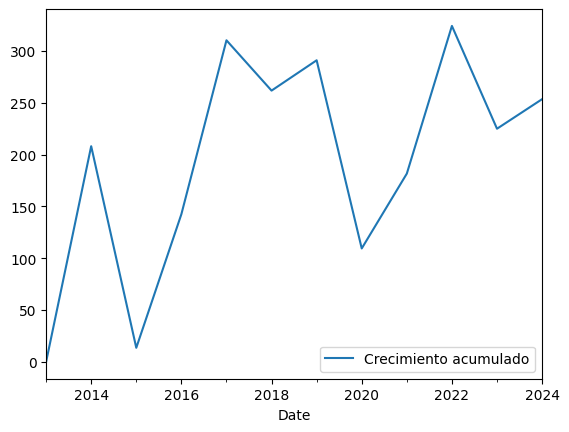

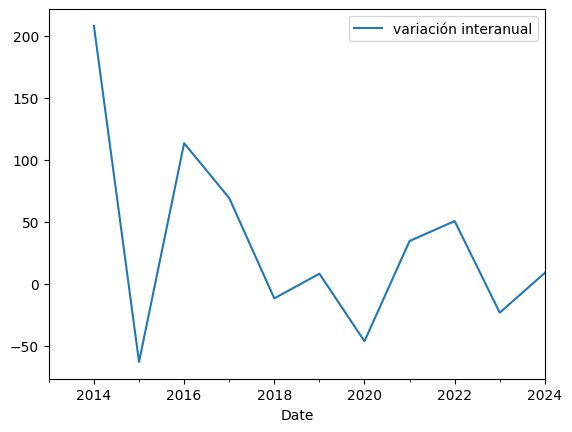

In [ ]:
temp = df_covid.groupby("Titulo")["value"].apply(lambda x: (x / x.iloc[0] - 1) * 100).rename('Crecimiento acumulado').reset_index()
temp = temp[temp["Titulo"]=="PIB Pesca"].reset_index()
df_pesca = df_covid[df_covid["Titulo"]=="PIB Pesca"].reset_index()
df_pesca['Crecimiento acumulado'] = temp['Crecimiento acumulado']
df_pesca.plot(x="Date",y="Crecimiento acumulado")
df_pesca.plot(x="Date", y = "variación interanual")

###Post COVID

In [ ]:
df_post, df_covid,n_post = Analisis_PIB(df_final,"los lagos","post",'01-01-2020')
df_post

,Crecimiento acumulado,Tendencia (Var),Media,Std,Volatilidad
Titulo,,,,,
PIB,29.878237,723.813225,9.6725,4.698307,Normal
PIB Administración pública,23.898748,38.483414,8.4175,3.196763,Normal
PIB Agropecuario-silvícola,39.608139,61.514443,9.8575,13.601440,Alta
PIB Comercio,6.875075,25.308314,9.3050,14.772909,Muy alta
PIB Construcción,16.608837,28.906493,8.7200,7.143365,Alta
PIB Electricidad gas y agua,82.432808,43.432093,10.7850,27.159888,Muy alta
PIB Industria manufacturera,21.021421,78.167375,6.0500,20.320815,Extremo
PIB Minería,67.149684,2.714322,14.2100,23.173380,Muy alta
PIB Pesca,25.498247,16.094528,17.6175,32.302869,Muy alta


### Comparacion Pre/Post - COVID

Siguiendo con el ejeplo de la pesca

El cambio en la tendencia nos indicara como sobrellevaron a grandes rasgos el shock de la pandemia 2020.


* \+ → + (más alta)	    ▶ Aceleración
* \+ → + (más baja)	    ▶ Desaceleración
* \+ → -	                ▶ Quiebre estructural
* \- → +	                ▶ Recuperación
* \- → - (más negativa)	▶ Deterioro
* \- → - (menos negativa)▶ Mejora parcial

In [ ]:
def tendencia_labels(pre, post):
  if pre > 0 :
    if post > 0:
      if pre < post:
        return "Aceleracion"
      else:
        return "Desaceleracion"
    else:
      return "Quiebre estructural"
  else:
    if post < 0:
      if pre < post:
        return "Mejora parcial"
      else:
        return "Deterioro"
    else:
      return "Recuperacion"


In [ ]:
def COVID_comparacion(df_pre,df_post,n_pre,n_post):

  df_postpre = ((df_post['Crecimiento acumulado']**(1/n_post) - 1) - (df_pre['Crecimiento acumulado']**(1/n_pre) - 1)).to_frame()
  df_postpre = df_postpre.rename(columns = {"Crecimiento acumulado":"Diff CAGR"})
  df_postpre["Estado del CARG"] = pd.cut(df_postpre["Diff CAGR"],bins=[-np.inf, -0.2, 0.2, np.inf], labels=["Deterioro", "Estancado", "Fortalecido"] )
  temp = df_pre[['Tendencia (Var)']].merge( df_post['Tendencia (Var)'],left_index=True,right_index=True,suffixes=("_pre", "_post"))
  df_postpre["Cambio en Tendencia"] = temp.apply(lambda row: tendencia_labels(row["Tendencia (Var)_pre"], row["Tendencia (Var)_post"]),axis=1)
  df_postpre["Cambio en Volatilidad"] = np.where(df_pre["Std"]/df_pre["Media"].abs() < df_post["Std"]/df_post["Media"].abs(), "Mayor Inestabilidad","Estabilizador")
  df_postpre["Diff Media"] = (df_post["Media"] - df_pre['Media'])
  return df_postpre

In [ ]:
COVID_comparacion(df_pre,df_post,n_pre,n_post)

,Diff CAGR,Estado del CARG,Cambio en Tendencia,Cambio en Volatilidad,Diff Media
Titulo,,,,,
PIB,0.462043,Fortalecido,Aceleracion,Estabilizador,-0.982500
PIB Administración pública,0.391231,Fortalecido,Aceleracion,Mayor Inestabilidad,-0.414167
PIB Agropecuario-silvícola,0.856860,Fortalecido,Aceleracion,Estabilizador,4.580833
PIB Comercio,-0.131267,Estancado,Desaceleracion,Mayor Inestabilidad,2.171667
PIB Construcción,0.036881,Estancado,Desaceleracion,Mayor Inestabilidad,-5.451667
PIB Electricidad gas y agua,1.284166,Fortalecido,Aceleracion,Mayor Inestabilidad,2.975000
PIB Industria manufacturera,0.116151,Estancado,Desaceleracion,Mayor Inestabilidad,-10.285000
PIB Minería,0.963400,Fortalecido,Aceleracion,Mayor Inestabilidad,2.916667
PIB Pesca,-0.001927,Estancado,Desaceleracion,Mayor Inestabilidad,-36.372500


Lo interesante de este dataframe que el rubro de "Restaunrates y hoteles" se vio fortalezido en la acumulacion relativa, pero la tendencia empeoro, lo que sugiere una dinamica que sufre efecto rebote del COVID mas que un crecimiento sostenible.

### Regiones

Volatilidad

In [ ]:
list_region_pre = []
list_region_post = []

for i in df_final.Región.unique()[1:]:
  df_temp_pre,_,n_pre = Analisis_PIB(df_final,i,"pre",'01-01-2020')
  list_region_pre.append([i,df_temp_pre])

  df_temp_post,_,n_post = Analisis_PIB(df_final,i,"post",'01-01-2020')
  list_region_post.append([i,df_temp_post])

for i, reg in enumerate(df_final.Región.unique()[1:]):
  print(reg, ":", list_region_pre[i][1]["Volatilidad"].value_counts(normalize=True).index[0])

Tarapacá : Baja
Antofagasta : Normal
Atacama : Extremo
Coquimbo : Normal
Valparaíso : Normal
Del libertador general bernardo ohiggins : Normal
Del maule : Normal
Del biobío : Alta
La araucanía : Normal
Los lagos : Normal
Aysén del general carlos ibáñez del campo : Alta
Magallanes y la antártica chilena : Alta
Metropolitana santiago : Normal
Los ríos : Normal
Arica y parinacota : Normal
Del ñuble : Alta


Cambio de tendencia

In [ ]:
list_comparacion =[]

for i, reg in enumerate(df_final.Región.unique()[1:]):
  list_comparacion.append([reg, COVID_comparacion(list_region_pre[i][1],list_region_post[i][1], n_pre, n_post)])

for i, reg in enumerate(df_final.Región.unique()[1:]):
  print(reg, ":", list_comparacion[i][1]["Cambio en Tendencia"].value_counts(normalize=True).index[0])

Tarapacá : Aceleracion
Antofagasta : Aceleracion
Atacama : Aceleracion
Coquimbo : Aceleracion
Valparaíso : Aceleracion
Del libertador general bernardo ohiggins : Aceleracion
Del maule : Aceleracion
Del biobío : Aceleracion
La araucanía : Aceleracion
Los lagos : Aceleracion
Aysén del general carlos ibáñez del campo : Aceleracion
Magallanes y la antártica chilena : Aceleracion
Metropolitana santiago : Aceleracion
Los ríos : Aceleracion
Arica y parinacota : Aceleracion
Del ñuble : Aceleracion


En todas las regiones la pendiente crecio mas que los años anteriores, eso debido a que el segundo periodo empieza con un pib muy bajo debido al covid, esto genera un efecto de rebote en la tendencia. Esto muestra un recuperacion del COVID a nivel regional, lo mas positivo es que no hubo quiebre estructural. Lo interesante a continuacion es averiguar si las regiones alcanzaron o alcanzaran las proyecciones que tenian antes del covid. (**En Desarrollo**)

Estado del CARG

In [ ]:
list_comparacion =[]

for i, reg in enumerate(df_final.Región.unique()[1:]):

  list_comparacion.append([reg, COVID_comparacion(list_region_pre[i][1],list_region_post[i][1], n_pre, n_post)])

for i, reg in enumerate(df_final.Región.unique()[1:]):
  print(reg, ":", list_comparacion[i][1]["Estado del CARG"].value_counts(normalize=True).index[0])

Tarapacá : Fortalecido
Antofagasta : Fortalecido
Atacama : Fortalecido
Coquimbo : Fortalecido
Valparaíso : Fortalecido
Del libertador general bernardo ohiggins : Fortalecido
Del maule : Fortalecido
Del biobío : Fortalecido
La araucanía : Fortalecido
Los lagos : Fortalecido
Aysén del general carlos ibáñez del campo : Fortalecido
Magallanes y la antártica chilena : Fortalecido
Metropolitana santiago : Fortalecido
Los ríos : Fortalecido
Arica y parinacota : Fortalecido
Del ñuble : Fortalecido


Al igual que el caso anterior, el carg se ve fortalecido por el hecho de que el COVID bajo mucho el PIB, cuando nos salvamos de la pandemia, hubo un repunte gigante en el crecimiento acumulado.

## Electricidad


**¿La generación eléctrica regional sigue o anticipa el crecimiento
del PIB?**
**¿El aumento en la generación eléctrica del año anterior se asocia
con un mayor PIB al año siguiente?**

### Generacion

In [ ]:
lista_electrcidad

['Generación eléctrica, MWh; ', 'Distribución eléctrica, MWh;']

In [ ]:
df_series_electricidad = siete.buscar(lista_electrcidad[0])

In [ ]:
df_electricidad = datos_regionales(ajuste_df_serie(df_series_electricidad))

In [ ]:
df_electricidad.drop(columns=["statusCode"],inplace=True)
df_electricidad["Región"] = df_electricidad["Región"].str.split(";",n=1,expand=True)[0].rename("Región")

In [ ]:
import matplotlib.dates as mdates

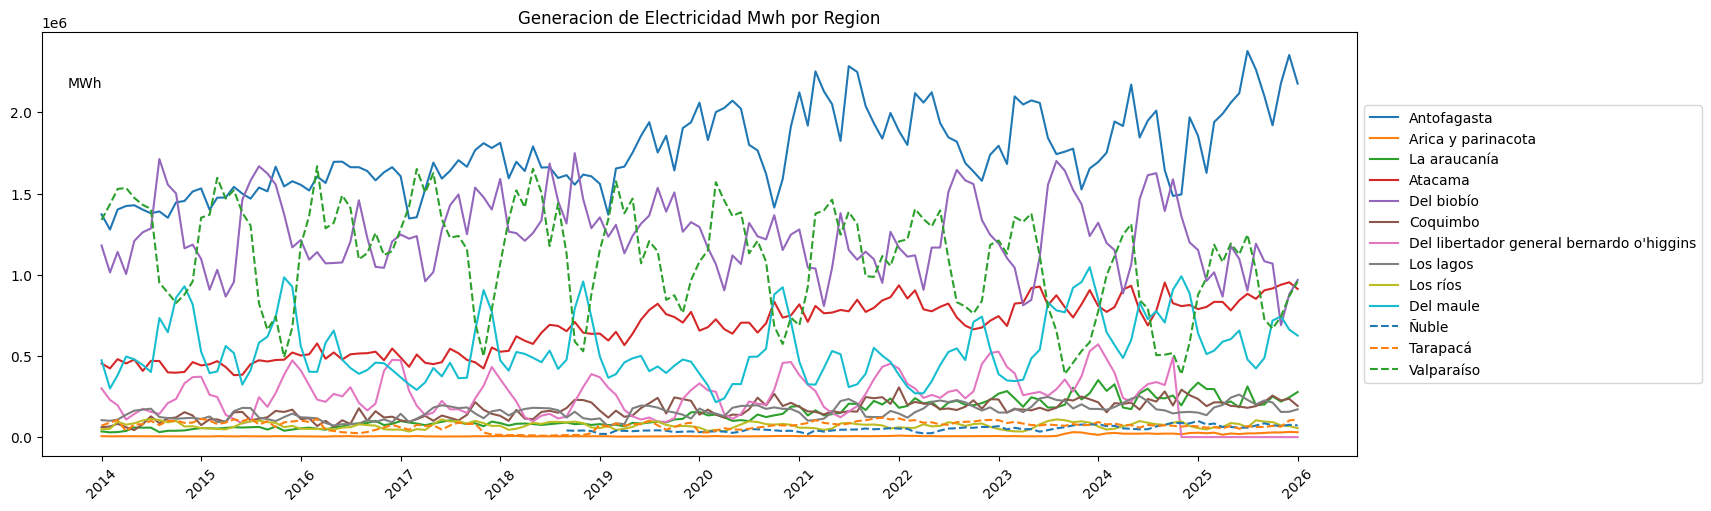

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(17, 5), layout='constrained')
df_electricidad["Date"] = pd.to_datetime(df_electricidad["Date"].astype(str),format="%Y-%d-%m")
j=0
for i in df_electricidad.Región.unique():
  j +=1
  temp = df_electricidad[df_electricidad["Región"] == i ]
  temp = temp.sort_values("Date")

  axs.set_title("MWh", loc='left', y=0.85, x=0.02, fontsize='medium')
  if j >10:
    axs.plot(temp["Date"].values,temp["value"].values,"--",label = i)
  else:
    axs.plot(temp["Date"].values,temp["value"].values,label = i)
  axs.legend(loc='center left', bbox_to_anchor=(1, 0.5))
  axs.set_title("Generacion de Electricidad Mwh por Region")

  #plot por estacion indicando el material particulado por dia, más una linea verde indicando su media

  #formato del ejex para las fechas
  #axs.xaxis.set_major_locator(mdates.MonthLocator(interval = 1))
  axs.xaxis.set_major_locator(mdates.YearLocator())
  axs.xaxis.set_major_formatter( mdates.DateFormatter('%Y'))
  plt.xticks(rotation=45)

Algo interesante de aqui es Valparaiso, se puede apreciar alrededor del 2021 que los peak de electricidad no son tan altos como antes, posiblemente debido al cierre progrsivo de plantas de carbon.

###Principales generadores

In [ ]:
df_electricidad.groupby("Región")["value"].sum().sort_values(ascending=False)[:3]

,value
Región,
Antofagasta,2.545870e+08
Del biobío,1.797749e+08
Valparaíso,1.599124e+08


### Distribuidores

In [ ]:
df_series_electricidad_dis = siete.buscar(lista_electrcidad[1])

In [ ]:
df_electricidad_dis = datos_regionales(ajuste_df_serie(df_series_electricidad_dis))

In [ ]:
df_electricidad_dis.drop(columns=["statusCode"],inplace=True)
df_electricidad_dis["Región"] = df_electricidad_dis["Región"].str.split(";",n=1,expand=True)[0].rename("Región")

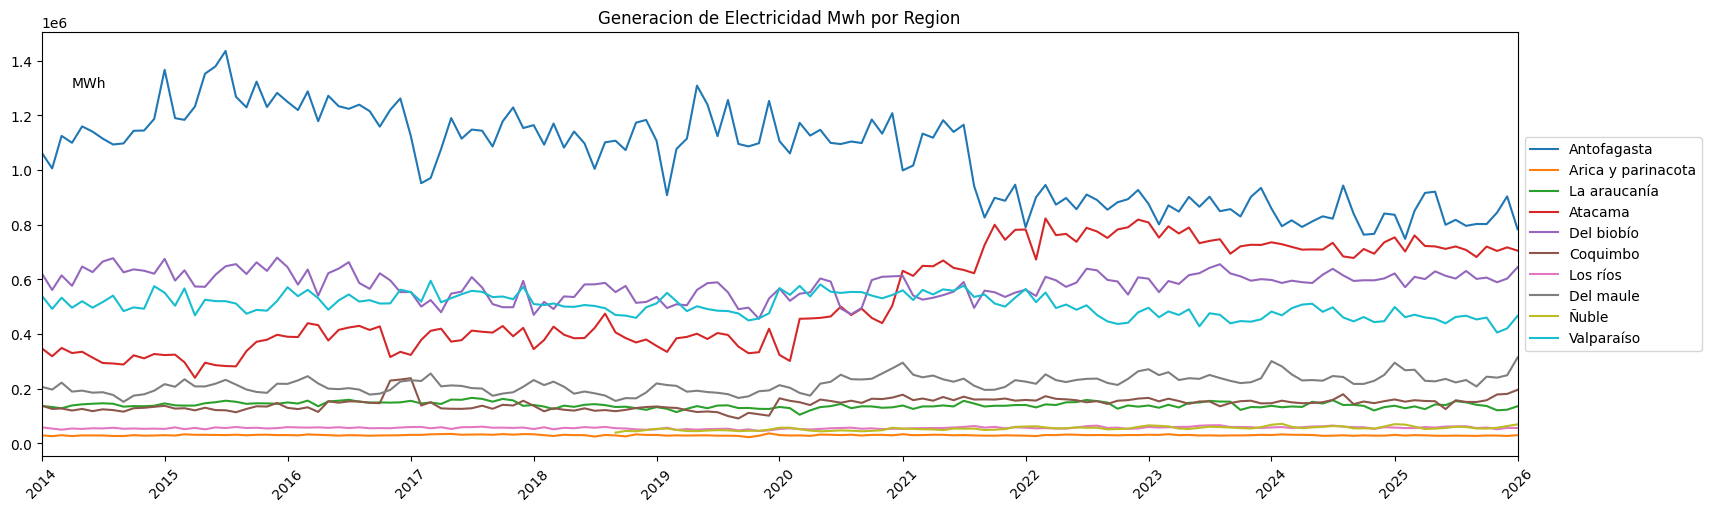

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(17, 5), layout='constrained')
df_electricidad_dis["Date"] = pd.to_datetime(df_electricidad_dis["Date"].astype(str),format="%Y-%d-%m")
for i in df_electricidad_dis.Región.unique():
  temp = df_electricidad_dis[df_electricidad_dis["Región"] == i ]
  temp = temp.sort_values("Date")

  axs.set_title("MWh", loc='left', y=0.85, x=0.02, fontsize='medium')
  axs.plot(temp["Date"],temp["value"],label = i)
  axs.legend(loc='center left', bbox_to_anchor=(1, 0.5))
  axs.set_title("Generacion de Electricidad Mwh por Region")

  #plot por estacion indicando el material particulado por dia, más una linea verde indicando su media

  #formato del ejex para las fechas
  #axs.xaxis.set_major_locator(mdates.MonthLocator(interval = 12))
  axs.xaxis.set_major_locator(mdates.YearLocator())
  axs.xaxis.set_major_formatter( mdates.DateFormatter('%Y'))

  axs.set_xlim(df_electricidad_dis["Date"].min(),
             df_electricidad_dis["Date"].max())
  plt.xticks(rotation=45)

### principales distribuidores

In [ ]:
df_electricidad_dis.groupby("Región")["value"].sum().sort_values(ascending=False)[:3]

,value
Región,
Antofagasta,151611160.0
Del biobío,84337717.0
Atacama,76070131.0


### Analisis con el PIB

In [ ]:

def correlacion_con_lag(serie_x, serie_y, lag=1):
    """
    Correlaciona serie_x rezagada con serie_y
    lag=1: ¿el valor del año anterior de X se relaciona con Y hoy?
    """
    x_lag = serie_x.shift(lag).dropna()
    y_alineado = serie_y.loc[x_lag.index]
    corr, pvalue = pearsonr(x_lag, y_alineado)
    return corr, pvalue

In [ ]:
df_electricidad_2024 = df_electricidad.copy()

In [ ]:
df_pib = df_final[df_final["Titulo"] == "PIB"]
df_pib = df_pib[~df_pib["Región"].isin(['Aysén del general carlos ibáñez del campo','Magallanes y la antártica chilena','Metropolitana santiago'])]
df_electricidad_2024["Región"] = df_electricidad_2024["Región"].str.replace( "Del libertador general bernardo o'higgins",  'Del libertador general bernardo ohiggins', regex=False)
df_pib["Región"] = df_pib["Región"].str.replace( "Del ñuble",  'Ñuble', regex=False)

In [ ]:
df_electrico_mean = df_electricidad_2024.groupby(['Región', df_electricidad_2024['Date'].dt.year])['value'].mean().reset_index()

In [ ]:
from scipy.stats import pearsonr

df_corre = pd.DataFrame()

for i in df_pib["Región"].unique():
  temp_pib = df_pib[df_pib.Región == i]
  temp_elec = df_electrico_mean[df_electrico_mean.Región == i]

  if i =="Ñuble":
    temp_pib = temp_pib[temp_pib["Date"] >"01-01-2017" ]
  else:
    temp_pib = temp_pib[temp_pib["Date"] >"01-01-2013" ]

  temp_elec = temp_elec[temp_elec["Date"] <2025 ]

  temp_pib = temp_pib.reset_index(drop=True)
  temp_elec = temp_elec.reset_index(drop=True)

  #Correlacion contemporanea
  corr_contem, pvalue_contem = pearsonr(temp_pib["value"], temp_elec["value"])

  #Correlacion con lag
  corr_lag, pvalue_lag = correlacion_con_lag(temp_elec["value"],temp_pib["value"])
  corr_lag_pe, pvalue_lag_pe = correlacion_con_lag(temp_pib["value"],temp_elec["value"])

  df_temp = pd.DataFrame({"Contemporaneo":[corr_contem],"p_1>0.05":[pvalue_contem > 0.05],"Lag: Elec -> PIB":[corr_lag],"p_2>0.05":[pvalue_lag > 0.05],"Lag: PIB -> Elec":[corr_lag_pe],"p_3>0.05":[pvalue_lag_pe > 0.05]},index =[i])

  df_corre = pd.concat([df_corre,df_temp], ignore_index=True)
df_corre.index = df_pib.Región.unique()

Ahora que tenemos la correlacion, seria interesante estudiar si la generacion y el pib crecen contemporaneamente (crecen juntos y al mismo tiempo), tambien si la generacion de electricidad o el pib del año anterior causa un crecimiento en alguno de ellos. Tambien como dato adicional se añadira la columna del principal servicio de la region.

In [ ]:
df_temp = df_tres_serv_per_region.Servicio_1.reset_index()
df_temp = df_temp[~df_temp["Región"].isin(['Aysén del general carlos ibáñez del campo','Magallanes y la antártica chilena','Metropolitana santiago'])]
df_temp["Región"] = df_temp["Región"].str.replace( "Del ñuble",  'Ñuble', regex=False)
df_temp.set_index("Región",inplace=True)

df_corre["Principal PIB"] = df_temp

df_corre

,Contemporaneo,p_1>0.05,Lag: Elec -> PIB,p_2>0.05,Lag: PIB -> Elec,p_3>0.05,Principal PIB
Tarapacá,0.293953,True,0.241795,True,0.384700,True,PIB Minería
Antofagasta,0.756014,False,0.898720,False,0.596277,True,PIB Minería
Atacama,0.888653,False,0.921589,False,0.837085,False,PIB Minería
Coquimbo,0.908614,False,0.894887,False,0.926275,False,PIB Minería
Valparaíso,-0.859433,False,-0.749377,False,-0.884245,False,PIB Servicios personales
Del libertador general bernardo ohiggins,0.714656,False,0.747804,False,0.705966,False,PIB Agropecuario-silvícola
Del maule,0.482133,True,0.086302,True,0.514412,True,PIB Agropecuario-silvícola
Del biobío,0.111139,True,-0.127870,True,0.136256,True,PIB Industria manufacturera
La araucanía,0.984235,False,0.993863,False,0.964678,False,PIB Servicios personales
Los lagos,0.846237,False,0.785390,False,0.869019,False,PIB Servicios personales


Rechazamos las filas y columnas donde el pvlue es True. Lo interesante se encuentra en el norte (Antofagasta y Atacama ) donde un el PIB tiene un mayor impacto cuando crece la generacion de electricidad del año anterior en la region, esto posiblemente debido al rubro minero. Mientras que algunas regiones (Los lagos, Ñuble y Arica y parinacota) con principal rubro los Servicios personales (Actividades deportivas, artisticas, de entretencion, peluquerias,etc...) arrastran la demanda energetica.

**CRUCE**

Correlacion mayor a 0.7, un pvalue menor a 5% y pib creciendo junto a la generacion de electricidad tenemos a :  

*   Araucanía
*   Ñuble
* Coquimbo
* Atacama
* Los Lagos
* Arica

Los demas presentan datos no significativos.

El dato interesante es Valparaíso, genera electricidad que no se traduce en crecimiento económico local, posiblemente por lo dicho antes, el cierre progresivo de las plantas a carbon. Su economía crece por servicios, comercio y turismo, no por industria electrointensiva.

####Comparacion de tendencias

In [ ]:
def comparativa_tendencia(df_1,df_2):
  x_norm =  (df_1["value"] - df_1["value"].mean())/df_1["value"].std()
  pendiente_1 = tendencia(x_norm)
  y_norm = (df_2["value"] - df_2["value"].mean())/df_2["value"].std()
  pendiente_2 = tendencia(y_norm)
  diff = pendiente_1 - pendiente_2
  return diff

In [ ]:
print("La generacion de electricidad y el pib normalizado:")
print(" ")
for i in df_pib["Región"].unique():
  temp_pib = df_pib[df_pib.Región == i]
  temp_elec = df_electrico_mean[df_electrico_mean.Región == i]

  if i =="Ñuble":
    temp_pib = temp_pib[temp_pib["Date"] >"01-01-2017" ]
  else:
    temp_pib = temp_pib[temp_pib["Date"] >"01-01-2013" ]

  temp_elec = temp_elec[temp_elec["Date"] <2025 ]

  diff = comparativa_tendencia(temp_pib, temp_elec).round(4)
  if diff>-0.2 and diff<0.2:
    print(f"En {i}, tienen un valor de {diff}", ", Crecen juntos")
  elif diff >0.2:
    print(f"En {i}, tienen un valor de {diff}", ", El PIB crece mas rapido")
  else:
    print(f"En {i}, tienen un valor de {diff}", ", Genera cada vez mas electricidad, pero no se refleja en el PIB")

La generacion de electricidad y el pib normalizado:
 
En Tarapacá, tienen un valor de 0.2449 , El PIB crece mas rapido
En Antofagasta, tienen un valor de 0.0273 , Crecen juntos
En Atacama, tienen un valor de -0.0096 , Crecen juntos
En Coquimbo, tienen un valor de 0.0039 , Crecen juntos
En Valparaíso, tienen un valor de 0.5191 , El PIB crece mas rapido
En Del libertador general bernardo ohiggins, tienen un valor de 0.0903 , Crecen juntos
En Del maule, tienen un valor de 0.2083 , El PIB crece mas rapido
En Del biobío, tienen un valor de 0.2824 , El PIB crece mas rapido
En La araucanía, tienen un valor de 0.003 , Crecen juntos
En Los lagos, tienen un valor de 0.0415 , Crecen juntos
En Los ríos, tienen un valor de 0.316 , El PIB crece mas rapido
En Arica y parinacota, tienen un valor de 0.0772 , Crecen juntos
En Ñuble, tienen un valor de 0.0344 , Crecen juntos


En todas las ciudades tienen un valor positivo en la generacion del pib y electricidad.

## Serie de tiempo

**¿Es posible predecir el PIB regional usando la generación eléctrica como variable anticipadora?**

```
# Esto tiene formato de código
```



En esta seccion vamos a experimentar un poco, se tratara de predecir el pib futuro usando la prediccion de la serie de tiempo de la generacion electrica.

El plan seria:
1. Entrenar dataset mensuale con ARIMA y SARIMA (más robusto)
2. Usar los datos de validacion y estudiar el error
3. Obtener los promedios mensuales de los datos de prediccion
4. Regresion: PIB = m Elec + b
5. Si todo sale con los datos de validacion del PIB; calcular el error de todo junto.

In [ ]:
df_electricidad_train = df_electricidad[df_electricidad["Date"].dt.year < 2023]
df_electricidad_val = df_electricidad[df_electricidad["Date"].dt.year >= 2023]

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

Primero revisaremos si pasa el test de Dickey-Fuller aumentado que mide si una serie es estacionaria o no, los criterios serian que el test sea suficientemente negativa para que el pvalue sea menor a 5%.

Reviso cada region:

In [ ]:
for i in df_electricidad_train.Región.unique():
  result = adfuller(df_electricidad_train[df_electricidad_train["Región"] == i].value)
  if result[0]<0 and result[1]<0.05:
    print(i,":")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(" ")

Arica y parinacota :
ADF Statistic: -3.6699179372427846
p-value: 0.0045567422848927
 
Los lagos :
ADF Statistic: -4.299523628683564
p-value: 0.0004450568700012955
 
Los ríos :
ADF Statistic: -3.0380995884414994
p-value: 0.03148633729877245
 
Del maule :
ADF Statistic: -4.62188228113752
p-value: 0.00011769070800080546
 
Tarapacá :
ADF Statistic: -3.274184678847669
p-value: 0.016072601095143847
 


Este test nos indica si para cierta region es sufientemente estacionario los datos para el uso del modelo ARIMA. Curiosamente algunos son regiones que necesitan PIB para generar electricidad el siguiente año, por lo que, no resulta buena idea hacerlo.
Ahora bien los datos de electricidad son mensuales, es decir tienen picos en ciertos meses del año, podemos experimentar haciendo diff de 6 y 12 meses (nos quita 12 datos).

In [ ]:
#Lag(6)
for i in df_electricidad_train.Región.unique():
  data = df_electricidad_train[df_electricidad_train["Región"] == i].value.diff(1)
  data = data.dropna()
  result = adfuller(data)
  if result[0]<0 and result[1]<0.05:
    print(i,":")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(" ")

Antofagasta :
ADF Statistic: -3.4342243039637745
p-value: 0.009846047368329731
 
Arica y parinacota :
ADF Statistic: -6.00667479905359
p-value: 1.609355846038301e-07
 
La araucanía :
ADF Statistic: -6.5926755728684805
p-value: 7.050232890748414e-09
 
Atacama :
ADF Statistic: -3.4253930069369742
p-value: 0.010123090469464316
 
Del biobío :
ADF Statistic: -7.421925803590967
p-value: 6.701291386225955e-11
 
Coquimbo :
ADF Statistic: -7.697181193469151
p-value: 1.3694224103746639e-11
 
Del libertador general bernardo o'higgins :
ADF Statistic: -10.394575840823842
p-value: 1.9805126370478136e-18
 
Los lagos :
ADF Statistic: -6.047646311257381
p-value: 1.3002364786126545e-07
 
Los ríos :
ADF Statistic: -6.825876052360847
p-value: 1.9485712565029917e-09
 
Del maule :
ADF Statistic: -7.169389466840928
p-value: 2.8304870530852786e-10
 
Ñuble :
ADF Statistic: -6.93237199484018
p-value: 1.0759082232724599e-09
 
Tarapacá :
ADF Statistic: -8.246262898631944
p-value: 5.543565004647456e-13
 
Valparaí

In [ ]:
#lag(12)
for i in df_electricidad_train.Región.unique():
  data = df_electricidad_train[df_electricidad_train["Región"] == i].value.diff(2)
  data = data.dropna()
  result = adfuller(data)
  if result[0]<0 and result[1]<0.05:
    print(i,":")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(" ")

Antofagasta :
ADF Statistic: -3.417056251857439
p-value: 0.010390986581865535
 
Arica y parinacota :
ADF Statistic: -5.790041432610056
p-value: 4.896436456499948e-07
 
La araucanía :
ADF Statistic: -2.9219580585694125
p-value: 0.04285351112464904
 
Atacama :
ADF Statistic: -3.363337387013084
p-value: 0.012274027451344087
 
Coquimbo :
ADF Statistic: -8.075078187236912
p-value: 1.5131185022240298e-12
 
Del libertador general bernardo o'higgins :
ADF Statistic: -3.1797379887009454
p-value: 0.021187891325274478
 
Los lagos :
ADF Statistic: -3.9303581270968664
p-value: 0.001822446737902534
 
Los ríos :
ADF Statistic: -7.3736831896439865
p-value: 8.835880842486064e-11
 
Del maule :
ADF Statistic: -3.8669651677894428
p-value: 0.002291874011425711
 
Ñuble :
ADF Statistic: -4.029861022676767
p-value: 0.0012619736749583154
 
Tarapacá :
ADF Statistic: -4.4393229379926415
p-value: 0.0002527145346681177
 
Valparaíso :
ADF Statistic: -4.311635610458977
p-value: 0.0004240483172808004
 


lag de 6 meses fue superior, haciendo que las regiones que si dependen de la generacion electrica (antofagasta y atacama) para el aumento del pib pase el test de estacionalidad. Por lo que, se puede usar ARIMA y SARIMA (modelo parecido a arima pero que considera periodos o ciclos de tiempo, como la generacion de electricidad (invierno mas, verano menos)).

verifiquemos la estacionalidad, en los siguientes graficos deberia haber una caida rapida en los primeros datos de lags.

In [ ]:
regiones = ["Antofagasta","Atacama","La araucanía"]# Regiones participantes, considerando esta vez la araucania


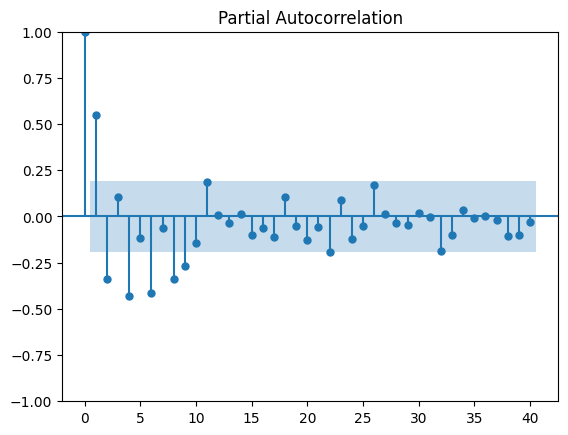

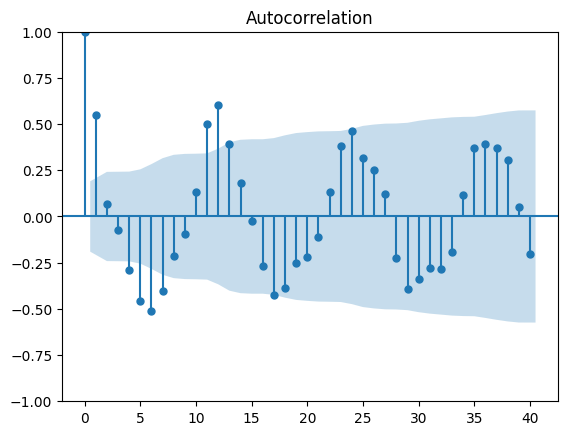

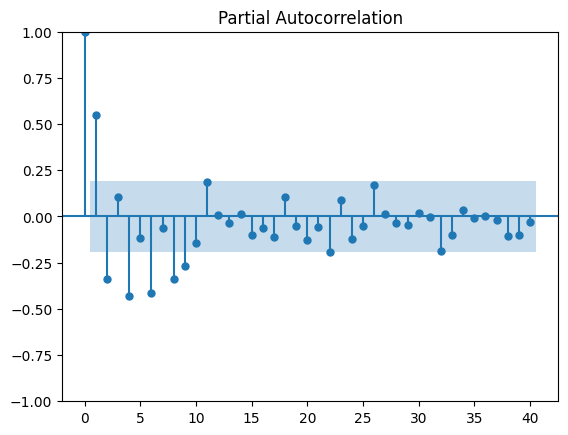

In [ ]:
data_train = df_electricidad_train[df_electricidad_train["Región"] == regiones[0]].value.diff(1)
data_train = data.dropna()
plot_acf(data_train, lags=40)
plot_pacf(data_train, lags=40)

Caida fuerte en AFC Y PAFC con diff 1, no hay estructura de definida para ar y ma.

---
Construccion de modelos ARIMA Y SARIMA

###Clases de modelos

#### model arima

In [ ]:
class modelo_ARIMA:
    def __init__(self, data,corte,region, scaling_log =False):
      self.data = data[data["Región"] == region]

      if scaling_log ==True:
        self.data.value = np.log(self.data.value)

      data_train = self.data[self.data["Date"].dt.year < corte]
      data_train = data_train.set_index('Date')
      data_train = data_train.asfreq('MS')

      data_test = self.data[self.data["Date"].dt.year >= corte]
      data_test = data_test.set_index('Date')
      data_test = data_test.asfreq('MS')

      self.train = data_train.value
      self.test = data_test.value

      self.model_fit = None
      self.forecast = None
      self.rmse = None

    def fit(self, order):
      model = ARIMA(self.train, order=order)
      self.model_fit = model.fit()


    def predict(self):
      self.forecast = self.model_fit.forecast(steps=len(self.test))
      return self.forecast

    def evaluate(self,imprimir=True):
        from sklearn.metrics import mean_squared_error
        import numpy as np
        # Mientras mas bajo se ajusta mejor
        if imprimir == True:
          print(f"AIC: {self.model_fit.aic}")
          print(f"BIC: {self.model_fit.bic}")

        self.rmse = np.sqrt(mean_squared_error(self.test, self.forecast))
        return self.rmse

    def model_summary(self):
      return self.model_fit.summary()

    def residual(self):
      # plot residual errors
      residuals = model_fit.resid
      residuals.hist(bins=30)
      plt.show()

    def plot(self):
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 5))
        plt.plot(self.train.index, self.train, label='Train', color='blue')
        plt.plot(self.test.index, self.test, label='Test', color='green')
        plt.plot(self.test.index, self.forecast, label='Forecast', color='red')

        plt.legend()
        plt.title('ARIMA Forecast vs Actual')
        plt.show()


    def buscar_parametros(self, orders):
        best_score = float("inf")
        best_params = None

        for order in orders:
              try:
                  self.fit(order)
                  self.predict()
                  rmse = self.evaluate(imprimir = False)

                  if rmse < best_score:
                      best_score = rmse
                      best_params = (order)

              except:
                  continue

        return best_params, best_score

    def export_data(self):
      return self.train, self.test

####model SARIMA


In [ ]:
class modelo_SARIMA:
    def __init__(self, data,corte,region,scaling_log = False):
      self.data = data[data["Región"] == region]

      if scaling_log ==True:
        self.data.value = np.log(self.data.value)

      data_train = self.data[self.data["Date"].dt.year < corte]
      data_train = data_train.set_index('Date')
      data_train = data_train.asfreq('MS')

      data_test = self.data[self.data["Date"].dt.year >= corte]
      data_test = data_test.set_index('Date')
      data_test = data_test.asfreq('MS')

      self.train = data_train.value
      self.test = data_test.value

      self.model_fit = None
      self.forecast = None
      self.rmse = None

    def fit(self, order, seasonal_order):
      model = SARIMAX(self.train, order=order, seasonal_order=seasonal_order)
      self.model_fit = model.fit(method='lbfgs')

    def predict(self):
        self.forecast = self.model_fit.forecast(steps=len(self.test))
        return self.forecast

    def evaluate(self,imprimir=True):
        from sklearn.metrics import mean_squared_error
        import numpy as np
        # Mientras mas bajo se ajusta mejor
        if imprimir == True:
          print(f"AIC: {self.model_fit.aic}")
          print(f"BIC: {self.model_fit.bic}")

        self.rmse = np.sqrt(mean_squared_error(self.test, self.forecast))
        return self.rmse

    def residual(self):
      # plot residual errors
      residuals = model_fit.resid
      residuals.hist(bins=30)
      plt.show()

    def plot(self):
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 5))
        plt.plot(self.train.index, self.train, label='Train', color='blue')
        plt.plot(self.test.index, self.test, label='Test', color='green')
        plt.plot(self.test.index, self.forecast, label='Forecast', color='red')

        plt.legend()
        plt.title('SARIMA Forecast vs Actual')
        plt.show()


    def buscar_parametros(self, orders, seasonal_orders):
        best_score = float("inf")
        best_params = None

        for order in orders:
            for s_order in seasonal_orders:
                try:
                    self.fit(order, s_order)
                    self.predict()
                    rmse = self.evaluate(imprimir = False)

                    if rmse < best_score:
                        best_score = rmse
                        best_params = (order, s_order)

                except:
                    continue

        return best_params, best_score

    def export_data(self):
      return self.train, self.test

###ARIMA

/tmp/ipykernel_13599/2713931081.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)


AIC: -241.48013333850557
BIC: -233.48981605616936
RMSE: 0.1308278400257584


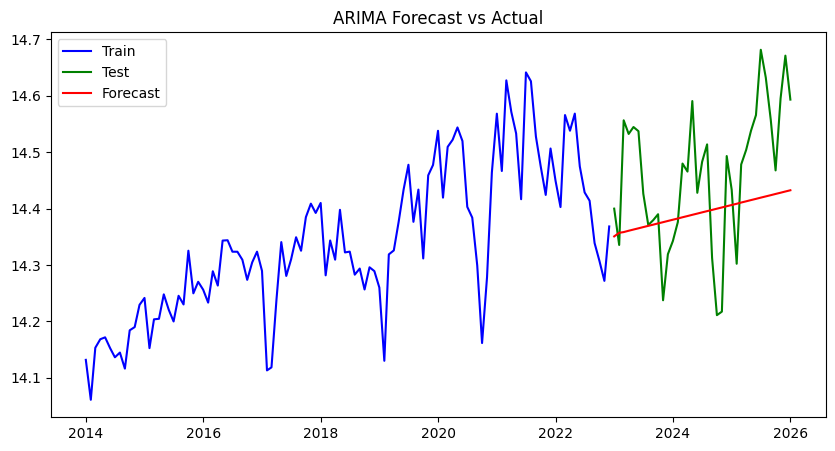

In [ ]:
p, d, q = 1, 2, 1
order = (p, d, q)
model = modelo_ARIMA(df_electricidad,2023,regiones[0],scaling_log = True)
model_fit = model.fit(order)
modelo_summary = model.model_summary()

modelo_summary
model.predict()
print(f"RMSE: {model.evaluate()}")
model.plot()

Busquemos los mejores parametros

In [ ]:
import itertools as itertools

In [ ]:
num_orders = [0,1,2,3] # probamos hasta (3,3,3)
ordes = list(itertools.combinations_with_replacement(num_orders,3))
best_order, error = model.buscar_parametros(ordes)
print(f"mejores parametros:{best_order} con error de {error}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.p

mejores parametros:(1, 2, 2) con error de 0.12060990334404434


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/tmp/ipykernel_13599/2713931081.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)


AIC: -243.03035151207789
BIC: -232.37659513562963
RMSE: 0.12060990334404434


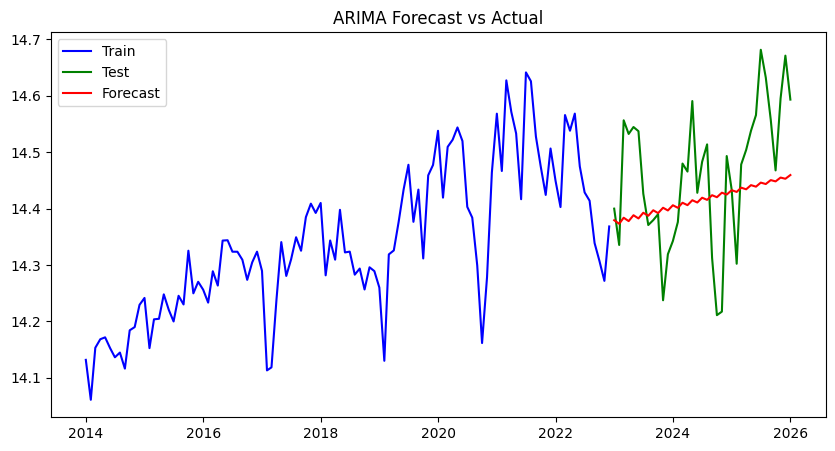

In [ ]:

model = modelo_ARIMA(df_electricidad,2023,regiones[0],scaling_log = True)
model_fit = model.fit(best_order)
modelo_summary = model.model_summary()

modelo_summary
model.predict()
print(f"RMSE: {model.evaluate()}")
model.plot()

Probando parametros, no se consigue un modelo interesante.

###SARIMA

/tmp/ipykernel_13599/2771389768.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)


AIC: -192.48577394872564
BIC: -184.85588960191564
RMSE: 0.474261126284118


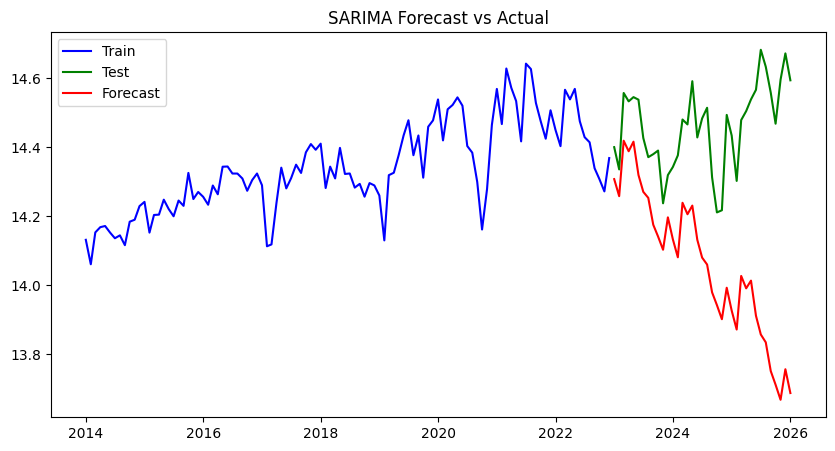

In [ ]:
p, d, q = 1, 2, 1
order = (p, d, q)
seasonal_order=(0,1,0,12)
model = modelo_SARIMA(df_electricidad,2023,regiones[0],scaling_log = True)
model_fit = model.fit(order,seasonal_order)

model.predict()
print(f"RMSE: {model.evaluate()}")
model.plot()

Buscamos los mejores parametros

In [ ]:
num_orders = [0,1,2]
orders = list(itertools.product(num_orders, repeat=3))
orders = [t for t in orders if t[1] <= 2]

seasonal_base = list(itertools.product([0,1], repeat=3))# evitar  Q >= 2, soluciona error de Non-invertible
seasonal_base = [t for t in seasonal_base if t[1] <= 1]# evitar D=2 # eliminar warning de
seasonal_orders = [t + (12,) for t in seasonal_base]

best_order, error = model.buscar_parametros(ordes,seasonal_orders)
print(f"mejores parametros:{best_order} con error de {error}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace

mejores parametros:((1, 1, 2), (0, 1, 0, 12)) con error de 0.09701573819261551


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/tmp/ipykernel_13599/2771389768.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data.value = np.log(self.data.value)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


AIC: -206.09424979857374
BIC: -195.8787422321716
RMSE: 0.09701573819261551


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


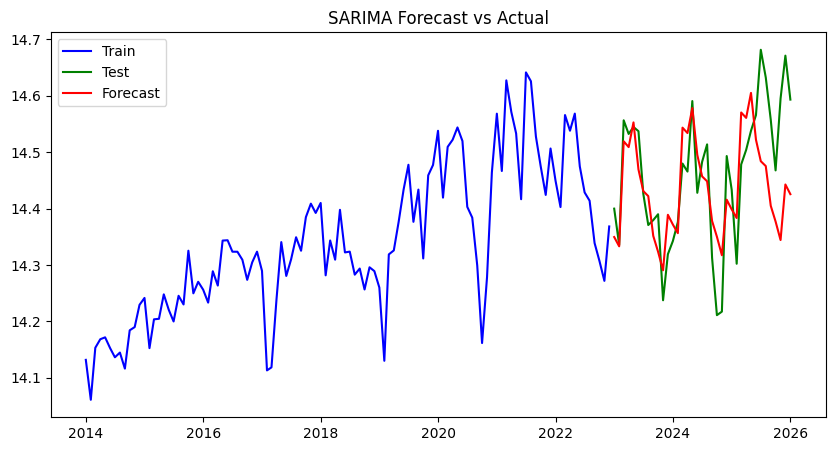

In [ ]:
model = modelo_SARIMA(df_electricidad,2023,regiones[0],scaling_log = True)
model_fit = model.fit(best_order[0],(best_order[1]))

model.predict()
print(f"RMSE: {model.evaluate()}")
model.plot()

##

##Predecir PIB

Esta prediccion es usando los datos contemporaneo, es decir generacion de electricidad 2024 predice el pib del 2024. Seria interesante luego predecir usando lag(1).

In [ ]:
data_train, data_test = model.export_data()

data_train = data_train.reset_index()
data_elec_train = data_train.groupby([ data_train['Date'].dt.year])['value'].mean()

data_test = data_test.reset_index()
data_elec_test = data_test.groupby([ data_test['Date'].dt.year])['value'].mean()

data_forescast = model.predict()
data_forescast = data_forescast.reset_index().rename(columns = {"index":"Date","predicted_mean":"value"})
data_forescast_test = data_forescast.groupby([ data_forescast['Date'].dt.year])['value'].mean()

data_pib = df_pib[df_pib["Región"] == "Antofagasta"]
data_pib_train = data_pib[(data_pib["Date"].dt.year>2013) & (data_pib["Date"].dt.year<2023)]
data_pib_test = data_pib[(data_pib["Date"].dt.year>=2023)]


In [ ]:
parametros = linregress(data_elec_train.values, data_pib_train.value)

In [ ]:
pib_predict_elec_real = parametros.slope*data_elec_test.values + parametros.intercept
pib_predict_elec_predict = parametros.slope*data_forescast_test.values + parametros.intercept

In [ ]:
df_prediccion_pib = pd.DataFrame(columns=["PIB","PIB prediccion elec test","error abs test","error rel test","PIB prediccion elec predict","error abs sarima","error rel sarima"])
df_prediccion_pib["PIB"] = np.concat([data_pib_test.value.values , np.array([None,None])])
df_prediccion_pib["PIB prediccion elec test"] = pib_predict_elec_real
df_prediccion_pib["PIB prediccion elec predict"] = pib_predict_elec_predict

df_prediccion_pib["error abs test"] = np.abs(df_prediccion_pib["PIB"] - df_prediccion_pib["PIB prediccion elec test"])
df_prediccion_pib["error abs sarima"] = np.abs(df_prediccion_pib["PIB"] - df_prediccion_pib["PIB prediccion elec predict"])

df_prediccion_pib["error rel test"] = df_prediccion_pib["error abs test"]/df_prediccion_pib["PIB"]
df_prediccion_pib["error rel sarima"] = df_prediccion_pib["error abs sarima"]/df_prediccion_pib["PIB"]

In [ ]:
df_prediccion_pib

,PIB,PIB prediccion elec test,error abs test,error rel test,PIB prediccion elec predict,error abs sarima,error rel sarima
0,28277.997339,21874.907309,6403.09003,0.226434,21543.262278,6734.735062,0.238162
1,33249.737198,21441.254738,11808.48246,0.355145,22682.531086,10567.206112,0.317813
2,None,27102.437126,NaN,NaN,23891.577978,NaN,NaN
3,None,29690.610689,NaN,NaN,22163.437508,NaN,NaN


Conclusion: El modelo SARIMA (mejor evaluado) no predice correctamente el pib usando el modelo propuesto (regresion). Pese a la escasa cantidad de datos hay un error relativo del 20 a 30 porciento, muy poco preciso. Falta explorar más los parametros, buscar otro modelo o experimentar con lag o modelos autoregresivos.

## Población

In [ ]:
siete.buscar(lista_dataset[0]).spanishTitle.unique()

array(['Tasa de desocupación, U. de Chile (porcentaje). Metodología descontinuada.',
       'Tasa de desocupación, U. de Chile (porcentaje). Metodología vigente',
       'Tasa de desocupación, hombres | Ajustada estacionalmente | INE | Mensual | Porcentaje',
       'Tasa de desocupación, mujeres | Ajustada estacionalmente | INE | Mensual | Porcentaje',
       'Tasa de desocupación, total | Ajustada estacionalmente | INE | Mensual | Porcentaje',
       'Tasa de desocupación, hombres | No Ajustada | INE | Mensual | Porcentaje',
       'Tasa de desocupación, mujeres | No Ajustada | INE | Mensual | Porcentaje',
       'Tasa de desocupación, total | No Ajustada | INE | Mensual | Porcentaje',
       'Tasa de desocupación, Región de Tarapacá, mensual INE',
       'Tasa de desocupación, Región de Antofagasta, mensual INE',
       'Tasa de desocupación, Región de Atacama, mensual INE',
       'Tasa de desocupación, Región de Coquimbo, mensual INE',
       'Tasa de desocupación, Región de Valpar

In [ ]:
serie_desocupacion = siete.buscar(lista_dataset[0]) # Tasa de desempleo
serie_empleo = siete.buscar(lista_dataset[1]) #  Miles de personas

In [ ]:
serie_desocupacion_mod = ajuste_df_serie(serie_desocupacion)
serie_empleo_mod = ajuste_df_serie(serie_empleo)


In [ ]:
df_final_desempleo = datos_regionales(serie_desocupacion_mod)
df_final_empleo = datos_regionales(serie_empleo_mod) # Ya viene con solamente con regiones


In [ ]:
df_final_desempleo[["Titulo","Sub"]] = df_final_desempleo["Titulo"].str.split("|",n=2,expand=True)[[0,1]]

In [ ]:
df_final_desempleo_reg = df_final_desempleo[df_final_desempleo["Región"].isna() == False]

In [ ]:
df_final_desempleo_reg.Región.unique() == df_final_empleo.Región.unique() #Mismo nombre de reionges? Si

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [ ]:
df_final_empleo[df_final_empleo['Región'] == "Los lagos"].value

,value
0,337.385693
1,337.915254
2,342.665359
3,341.469397
4,336.991657
...,...
186,409.038323
187,408.073639
188,404.985129
189,406.263336


In [ ]:
df_final_desempleo_reg[df_final_desempleo_reg['Región'] == "Los lagos"].value

,value
0,7.174488
1,7.120925
2,7.666831
3,8.626787
4,8.497949
...,...
186,5.493808
187,6.586342
188,6.815972
189,6.443209


In [ ]:
df_final_desempleo_reg[df_final_desempleo_reg['Date'] == "2025-01-11"]

,Date,value,statusCode,Titulo,Región,Sub
188,2025-01-11,9.052228,OK,Tasa de desocupación,Tarapacá,None
188,2025-01-11,6.636536,OK,Tasa de desocupación,Antofagasta,None
188,2025-01-11,9.066061,OK,Tasa de desocupación,Atacama,None
188,2025-01-11,7.527107,OK,Tasa de desocupación,Coquimbo,None
188,2025-01-11,8.023588,OK,Tasa de desocupación,Valparaíso,None
188,2025-01-11,7.898955,OK,Tasa de desocupación,Del libertador gral. bernardo o'higgins,None
188,2025-01-11,7.665015,OK,Tasa de desocupación,Del maule,None
188,2025-01-11,9.877050,OK,Tasa de desocupación,Del biobío,None
188,2025-01-11,8.307204,OK,Tasa de desocupación,La araucanía,None
188,2025-01-11,6.815972,OK,Tasa de desocupación,Los lagos,None


In [ ]:
siete.buscar("Población").spanishTitle.unique()

array(['Población de 14 años y más, U. de Chile (miles de personas). Metodología descontinuada.',
       'Población de 14 años y más, U. de Chile (miles de personas). Metodología vigente',
       'Población de 15 años y más, mensual, INE (promedios móviles trimestrales, miles de personas)',
       'Población de 15 años y más, INE ',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por género, 15 a 19 años; nominal; stock; mensual; miles de personas; INE',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por género, 20 a 24 años; nominal; stock; mensual; miles de personas; INE',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por género, 25 a 29 años; nominal; stock; mensual; miles de personas; INE',
       'Población hombres ; Fuerza de trabajo nacional, empleo, desocupados e inactivos por tramo de edad y por g

#Exportar Datos


In [ ]:
'''import json

reg = pd.read_json("cl.json")'''

'import json\n\nreg = pd.read_json("cl.json")'

In [ ]:
'''for i in range(reg.shape[0]):
  print(reg["features"][i]["properties"]["name"])'''

'for i in range(reg.shape[0]):\n  print(reg["features"][i]["properties"]["name"])'

In [ ]:
trans_reg = {
 'Del libertador general bernardo ohiggins':"Libertador General Bernardo O'Higgins",
 'Del maule':'Maule',
  'Del biobío':'Bío-Bío',
 'La araucanía':'La Araucanía',
 'Aysén del general carlos ibáñez del campo':'Aisén del General Carlos Ibáñez del Campo',
 'Magallanes y la antártica chilena':'Magallanes y Antártica Chilena',
 'Metropolitana santiago':'Región Metropolitana de Santiago',
 'Los ríos':'Los Ríos',
 'Arica y parinacota':'Arica y Parinacota',
 'Ñuble':'Ñuble'}

In [ ]:
df_pib_export = df_final[df_final["Titulo"] == "PIB"]
df_pib_export["Región"] = df_pib_export["Región"].replace(trans_reg)
df_pib_export.to_csv('datos_pib.csv', index=False, encoding='utf-8')


/tmp/ipykernel_13599/1539313659.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pib_export["Región"] = df_pib_export["Región"].replace(trans_reg)


In [ ]:
df_serv_export = df_final[df_final.Región.isna() == False]
df_serv_export = df_serv_export[df_serv_export["Titulo"] != "PIB"]
df_serv_export.Titulo = df_serv_export.Titulo.str.replace("PIB ","")
df_serv_export["Región"] = df_serv_export["Región"].replace(trans_reg)
df_serv_export.to_csv('datos_serv.csv', index=False, encoding='utf-8')


In [ ]:
df_tendencia_export = pd.DataFrame(list_tendencia, columns=["Región","serv_actual","serv_tendencia","years"])
df_tendencia_export.serv_actual = df_tendencia_export.serv_actual.str.replace("PIB ","")
df_tendencia_export.serv_tendencia = df_tendencia_export.serv_tendencia.str.replace("PIB ","")

df_tendencia_export["Región"] = df_tendencia_export["Región"].replace(trans_reg)
df_tendencia_export.to_csv('datos_serv_tendencia.csv', index=False, encoding='utf-8')

In [ ]:
df_final.Región.unique()[0]

In [ ]:
df_final_servicios["Región"].unique()

array(['Tarapacá', 'Antofagasta', 'Atacama', 'Coquimbo', 'Valparaíso',
       'Del libertador general bernardo ohiggins', 'Del maule',
       'Del biobío', 'La araucanía', 'Los lagos',
       'Aysén del general carlos ibáñez del campo',
       'Magallanes y la antártica chilena', 'Metropolitana santiago',
       'Los ríos', 'Arica y parinacota', 'Del ñuble'], dtype=object)